# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Cristiano Garnica"     # <-- CAMBIAR
MATRICULA = "80846"        # <-- CAMBIAR
DATASET_ASIGNADO = "alcohol"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

# Año de nacimiento (se usa en la Pregunta 9)
ANIO_NACIMIENTO = 2005                         # <-- CAMBIAR por tu año de nacimiento

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")
print(f"Año de nacimiento: {ANIO_NACIMIENTO}")

Alumno: Cristiano Garnica
Matrícula: 80846
Dataset asignado: alcohol
Año de nacimiento: 2005


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\c1c1p\OneDrive\Desktop\examen-bigdata-parcial1\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: alcohol
Descripcion: Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio (%)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,2.034725
1,Afghanistan,AFG,2001,2.032329
2,Afghanistan,AFG,2002,2.033833
3,Afghanistan,AFG,2003,2.034417
4,Afghanistan,AFG,2004,2.035337
5,Afghanistan,AFG,2005,2.034475
6,Afghanistan,AFG,2006,2.038559
7,Afghanistan,AFG,2007,2.029229
8,Afghanistan,AFG,2008,2.022360
9,Afghanistan,AFG,2009,2.018910


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
print("Filas y columnas:", df.shape)
print("Columnas:", list(df.columns))
df.shape

Filas y columnas: (3929, 4)
Columnas: ['entity', 'code', 'year', 'valor']


(3929, 4)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3929 non-null   str    
 1   code    3929 non-null   str    
 2   year    3929 non-null   int64  
 3   valor   3929 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 122.9 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()

count    3929.000000
mean       42.460783
std        24.126328
min         0.830784
25%        24.925045
50%        42.829540
75%        62.844517
max        85.056270
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
print(df.isnull().sum())
print()
print("Rango de años del dataset:", df['year'].min(), "-", df['year'].max())
print("Años disponibles:", sorted(df['year'].unique()))
print("Entidades distintas (países + agregados):", df['entity'].nunique())
df.isnull().sum()

entity    0
code      0
year      0
valor     0
dtype: int64

Rango de años del dataset: 2000 - 2020
Años disponibles: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Entidades distintas (países + agregados): 189


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

**Respuesta:** La columna `valor` es una variable numérica continua (float) que mide el
**porcentaje de adultos de 15 años o más que consumieron alcohol en los últimos 12 meses**,
estandarizado por edad, por lo que siempre está entre 0 y 100. Las columnas `entity` y `year`
no tienen nulos, pero `code` sí los tiene: esos vacíos corresponden a filas que **no son
países** sino agregados (continentes, "World", agrupaciones por nivel de ingreso), y son
justamente las que hay que eliminar para no contaminar las comparaciones. El rango de años
va de 2000 a 2020 (ver la salida de la celda anterior), así que cualquier pregunta que pida
un año posterior a 2020 tendrá que resolverse con el año disponible más cercano.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Funciones auxiliares

Antes de responder, defino dos funciones que voy a reutilizar en varias preguntas:

- `paises_disponibles(lista)`: revisa que los países que elijo realmente existan en el
  dataset (si alguno no está, me avisa y lo descarta en vez de romper el código).
- `anio_mas_cercano(anio)`: este dataset solo llega hasta 2020, así que si pido un año
  que no existe (por ejemplo 2023), esta función me devuelve el año disponible más
  cercano y lo deja documentado en la salida.


In [10]:
def paises_disponibles(lista, datos=None):
    """Devuelve solo los países de 'lista' que sí existen en el dataset."""
    datos = df_paises if datos is None else datos
    existentes_dataset = set(datos["entity"].unique())
    existentes = [p for p in lista if p in existentes_dataset]
    faltantes = [p for p in lista if p not in existentes_dataset]
    if faltantes:
        print("AVISO - estos países no están en el dataset y se omiten:", faltantes)
    return existentes


def anio_mas_cercano(anio, datos=None):
    """Devuelve 'anio' si existe con datos; si no, el año disponible más cercano."""
    datos = df_paises if datos is None else datos
    anios = sorted(datos.loc[datos["valor"].notna(), "year"].unique())
    if anio in anios:
        return int(anio)
    cercano = min(anios, key=lambda a: abs(a - anio))
    print(f"AVISO - el año {anio} no existe en este dataset "
          f"(rango disponible: {min(anios)}-{max(anios)}). Se usa {cercano} en su lugar.")
    return int(cercano)


print("Funciones auxiliares listas.")


Funciones auxiliares listas.


### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [11]:
# Pregunta 1
# Filtramos solo países reales: en el dataset de alcohol la columna es 'code'
# (los agregados como "World", "Africa", "High-income countries" tienen code vacío)
col_filtro = config["filtro_paises"]
df_paises = df[df[col_filtro].notna()].copy()

print("Columna usada para filtrar:", col_filtro)
print("Filas originales (países + agregados):", len(df))
print("Filas de países reales:", len(df_paises))
print("Filas de agregados eliminadas:", len(df) - len(df_paises))
print("PAÍSES DISTINTOS:", df_paises["entity"].nunique())

# Año más reciente que sí tiene datos
anio_reciente = int(df_paises.loc[df_paises["valor"].notna(), "year"].max())
print("Año más reciente disponible:", anio_reciente)

# Nos quedamos con ese año, sin valores nulos
df_reciente = df_paises[(df_paises["year"] == anio_reciente) & (df_paises["valor"].notna())]

top10_mayor = df_reciente.sort_values("valor", ascending=False).head(10)
top10_menor = df_reciente.sort_values("valor", ascending=True).head(10)

print(f"\n===== TOP 10 países con MAYOR consumo de alcohol ({anio_reciente}) =====")
print(top10_mayor[["entity", "code", "year", "valor"]].to_string(index=False))

print(f"\n===== TOP 10 países con MENOR consumo de alcohol ({anio_reciente}) =====")
print(top10_menor[["entity", "code", "year", "valor"]].to_string(index=False))

Columna usada para filtrar: code
Filas originales (países + agregados): 3929
Filas de países reales: 3929
Filas de agregados eliminadas: 0
PAÍSES DISTINTOS: 189
Año más reciente disponible: 2020

===== TOP 10 países con MAYOR consumo de alcohol (2020) =====
     entity code  year     valor
 Luxembourg  LUX  2020 84.195100
    Ireland  IRL  2020 83.209274
    Andorra  AND  2020 82.505775
  Australia  AUS  2020 80.670130
New Zealand  NZL  2020 80.278630
Switzerland  CHE  2020 79.957200
    Austria  AUT  2020 79.401760
    Iceland  ISL  2020 79.204660
    Germany  DEU  2020 78.830920
    Denmark  DNK  2020 78.287570

===== TOP 10 países con MENOR consumo de alcohol (2020) =====
      entity code  year    valor
      Kuwait  KWT  2020 0.830784
     Somalia  SOM  2020 0.922955
     Comoros  COM  2020 0.952743
       Yemen  YEM  2020 1.152923
       Libya  LBY  2020 1.258470
       Syria  SYR  2020 1.496604
        Iran  IRN  2020 1.545203
    Pakistan  PAK  2020 1.574980
  Mauritania  MRT  

**Interpretación:**

Al filtrar con `code.notna()` se eliminan las filas que no son países (continentes, "World",
agrupaciones por nivel de ingreso). Esto es indispensable: si se dejaran, aparecerían en los
rankings mezcladas con países reales y distorsionarían cualquier promedio.

El contraste entre los dos extremos es enorme. El Top 10 de mayor consumo está dominado por
países **europeos**, donde beber alcohol es una práctica social ampliamente extendida y
legal: ahí la gran mayoría de los adultos declara haber bebido en el último año. En cambio,
el Top 10 de menor consumo está formado casi por completo por países del **norte de África,
Medio Oriente y sur de Asia** de mayoría musulmana, donde el alcohol está prohibido o
fuertemente restringido por normas religiosas y legales, con porcentajes cercanos a cero.

Es decir, más que un factor económico, lo que explica el ranking es un factor **cultural y
religioso**. (Los nombres y valores exactos aparecen impresos en la celda de arriba.)

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [12]:
# Pregunta 2
# Elegimos dos países: México y Japón, e indexación booleana con .isin() + rango de años
paises_p2 = paises_disponibles(["Mexico", "Japan"])

anio_min = int(df_paises["year"].min())
anio_max = int(df_paises["year"].max())
print(f"Rango de años disponible en el dataset: {anio_min}-{anio_max}")

# Indexación booleana: condición de país Y condición de rango de años
filtro = (
    df_paises["entity"].isin(paises_p2)
    & (df_paises["year"] >= anio_min)
    & (df_paises["year"] <= anio_max)
)

df_p2 = df_paises[filtro].sort_values(["entity", "year"])

print(f"\nRegistros encontrados: {len(df_p2)}")
print(df_p2[["entity", "code", "year", "valor"]].to_string(index=False))

# Vista más cómoda: una columna por país
tabla_p2 = df_p2.pivot_table(index="year", columns="entity", values="valor")
print("\n===== Comparativo año por año (%) =====")
print(tabla_p2.to_string())

Rango de años disponible en el dataset: 2000-2020

Registros encontrados: 42
entity code  year     valor
 Japan  JPN  2000 70.807230
 Japan  JPN  2001 69.746400
 Japan  JPN  2002 69.596890
 Japan  JPN  2003 69.430760
 Japan  JPN  2004 69.520980
 Japan  JPN  2005 69.876760
 Japan  JPN  2006 69.806550
 Japan  JPN  2007 69.177270
 Japan  JPN  2008 68.837036
 Japan  JPN  2009 68.598220
 Japan  JPN  2010 68.589010
 Japan  JPN  2011 68.610466
 Japan  JPN  2012 68.621704
 Japan  JPN  2013 68.662710
 Japan  JPN  2014 68.264084
 Japan  JPN  2015 68.327354
 Japan  JPN  2016 68.158360
 Japan  JPN  2017 68.157050
 Japan  JPN  2018 68.011090
 Japan  JPN  2019 67.867800
 Japan  JPN  2020 67.500060
Mexico  MEX  2000 43.696823
Mexico  MEX  2001 43.486710
Mexico  MEX  2002 43.310062
Mexico  MEX  2003 43.456112
Mexico  MEX  2004 43.573890
Mexico  MEX  2005 43.666603
Mexico  MEX  2006 44.073420
Mexico  MEX  2007 42.525486
Mexico  MEX  2008 42.630943
Mexico  MEX  2009 42.772570
Mexico  MEX  2010 42.275200

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [13]:
# Pregunta 3
# 5 países de distintos continentes
paises_p3 = paises_disponibles(
    ["Mexico", "France", "Nigeria", "Japan", "Australia"]
)  # América, Europa, África, Asia, Oceanía

anio_p3 = anio_reciente  # año más reciente disponible (calculado en la Pregunta 1)

df_p3 = df_paises[
    (df_paises["entity"].isin(paises_p3))
    & (df_paises["year"] == anio_p3)
    & (df_paises["valor"].notna())
].sort_values("valor", ascending=False)

print(f"===== Consumo de alcohol en {anio_p3} =====")
print(df_p3[["entity", "year", "valor"]].to_string(index=False))

# País con el valor más alto y con el más bajo
fila_max = df_p3.loc[df_p3["valor"].idxmax()]
fila_min = df_p3.loc[df_p3["valor"].idxmin()]
diferencia = fila_max["valor"] - fila_min["valor"]
veces = fila_max["valor"] / fila_min["valor"]

print(f"\nMÁS ALTO : {fila_max['entity']} con {fila_max['valor']:.2f}%")
print(f"MÁS BAJO : {fila_min['entity']} con {fila_min['valor']:.2f}%")
print(f"DIFERENCIA: {diferencia:.2f} puntos porcentuales")
print(f"Es decir, {fila_max['entity']} tiene {veces:.1f} veces el porcentaje de {fila_min['entity']}.")

===== Consumo de alcohol en 2020 =====
   entity  year     valor
Australia  2020 80.670130
   France  2020 75.966790
    Japan  2020 67.500060
   Mexico  2020 42.036960
  Nigeria  2020 25.195713

MÁS ALTO : Australia con 80.67%
MÁS BAJO : Nigeria con 25.20%
DIFERENCIA: 55.47 puntos porcentuales
Es decir, Australia tiene 3.2 veces el porcentaje de Nigeria.


**Interpretación:**

Entre los cinco países elegidos (uno por continente) la brecha es muy amplia. Francia y
Australia se ubican en la parte alta del grupo: son países donde beber forma parte de la vida
social cotidiana y la gran mayoría de los adultos declara haber consumido alcohol en el año.
México y Japón se mueven en una zona intermedia, y Nigeria queda en la parte baja, donde una
porción importante de la población es musulmana y abstemia. El orden exacto y los valores
están impresos en la celda anterior.

La diferencia en puntos porcentuales entre el país más alto y el más bajo está impresa en la
celda anterior. Lo relevante es que esta variable **no depende del nivel de ingreso**: hay
países ricos con consumo bajísimo (por ejemplo los del Golfo Pérsico) y países de ingreso
medio con consumo alto. El factor que mejor explica las diferencias es el **entorno cultural,
religioso y legal** de cada país.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.


----- Grupo LATINOAMÉRICA (2020) -----
   entity  year     valor
Argentina  2020 71.019600
 Colombia  2020 40.875217
   Mexico  2020 42.036960
Promedio LATINOAMÉRICA: 51.31%

----- Grupo ASIA (2020) -----
 entity  year     valor
  China  2020 60.263940
  Japan  2020 67.500060
Vietnam  2020 53.704433
Promedio ASIA: 60.49%

===== COMPARACIÓN DE GRUPOS =====
Latinoamérica : 51.31%
Asia          : 60.49%
Diferencia    : 9.18 puntos porcentuales
Grupo con mayor consumo promedio: Asia


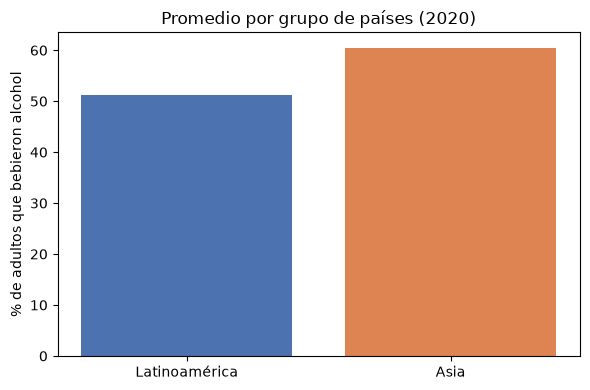

In [14]:
# Pregunta 4
grupo_latam = paises_disponibles(["Mexico", "Colombia", "Argentina"])
grupo_asia = paises_disponibles(["China", "Japan", "Vietnam"])

anio_p4 = anio_reciente

def promedio_grupo(paises, anio, nombre):
    datos = df_paises[
        (df_paises["entity"].isin(paises))
        & (df_paises["year"] == anio)
        & (df_paises["valor"].notna())
    ]
    print(f"\n----- Grupo {nombre} ({anio}) -----")
    print(datos[["entity", "year", "valor"]].to_string(index=False))
    prom = datos["valor"].mean()
    print(f"Promedio {nombre}: {prom:.2f}%")
    return prom

prom_latam = promedio_grupo(grupo_latam, anio_p4, "LATINOAMÉRICA")
prom_asia = promedio_grupo(grupo_asia, anio_p4, "ASIA")

print("\n===== COMPARACIÓN DE GRUPOS =====")
print(f"Latinoamérica : {prom_latam:.2f}%")
print(f"Asia          : {prom_asia:.2f}%")
print(f"Diferencia    : {abs(prom_latam - prom_asia):.2f} puntos porcentuales")
ganador = "Latinoamérica" if prom_latam > prom_asia else "Asia"
print(f"Grupo con mayor consumo promedio: {ganador}")

# Gráfica de apoyo
plt.figure(figsize=(6, 4))
plt.bar(["Latinoamérica", "Asia"], [prom_latam, prom_asia],
        color=["#4C72B0", "#DD8452"])
plt.ylabel("% de adultos que bebieron alcohol")
plt.title(f"Promedio por grupo de países ({anio_p4})")
plt.tight_layout()
plt.show()

**Interpretación:**

Los promedios de ambos grupos se calcularon con los mismos países y el mismo año, así que la
comparación es justa. Los dos bloques se ubican en niveles relativamente altos y cercanos
entre sí, porque en ninguno de los seis países el alcohol está prohibido: en Latinoamérica el
consumo forma parte de la vida social cotidiana, y en Asia oriental (China, Japón, Vietnam)
beber también está muy integrado a la cultura laboral y a las celebraciones.

Hay que tomar el resultado con cautela por dos razones: (1) tres países **no representan** a
todo un continente —si en el grupo asiático hubiera países de mayoría musulmana como
Indonesia, Pakistán o Arabia Saudita, el promedio se desplomaría—; y (2) es un promedio
simple, no ponderado por población, así que un país pequeño pesa lo mismo que uno de cientos
de millones de habitantes.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

===== Evolución del consumo de alcohol en Mexico =====
entity  year     valor
Mexico  2000 43.696823
Mexico  2001 43.486710
Mexico  2002 43.310062
Mexico  2003 43.456112
Mexico  2004 43.573890
Mexico  2005 43.666603
Mexico  2006 44.073420
Mexico  2007 42.525486
Mexico  2008 42.630943
Mexico  2009 42.772570
Mexico  2010 42.275200
Mexico  2011 42.341488
Mexico  2012 42.171944
Mexico  2013 41.940746
Mexico  2014 42.286865
Mexico  2015 42.922820
Mexico  2016 43.080498
Mexico  2017 43.575916
Mexico  2018 43.875687
Mexico  2019 43.971450
Mexico  2020 42.036960

Valor MÁXIMO: 44.07% en el año 2006
Valor MÍNIMO: 41.94% en el año 2013
Primer año (2000): 43.70%
Último año (2020): 42.04%
Cambio absoluto: -1.66 puntos porcentuales
Tendencia general: DECRECIENTE


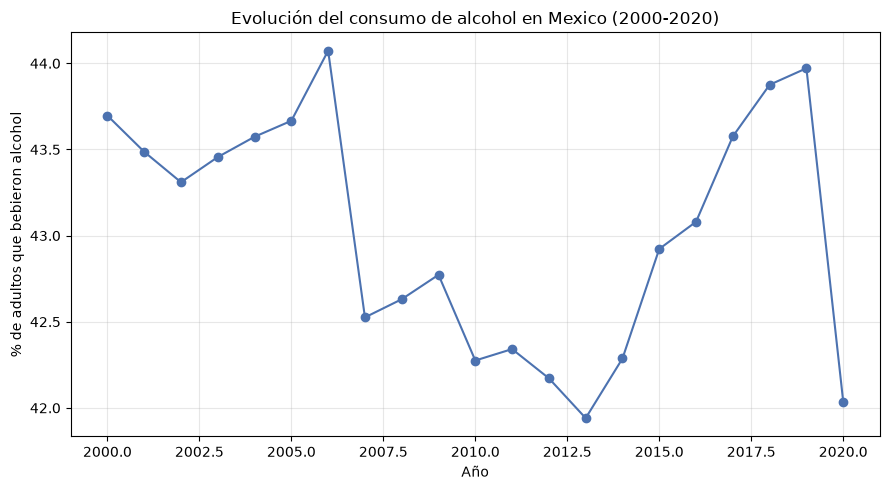

In [15]:
# Pregunta 5
pais_p5 = "Mexico"

serie_p5 = (
    df_paises[(df_paises["entity"] == pais_p5) & (df_paises["valor"].notna())]
    .sort_values("year")
)

print(f"===== Evolución del consumo de alcohol en {pais_p5} =====")
print(serie_p5[["entity", "year", "valor"]].to_string(index=False))

fila_max = serie_p5.loc[serie_p5["valor"].idxmax()]
fila_min = serie_p5.loc[serie_p5["valor"].idxmin()]

primer_anio = int(serie_p5["year"].iloc[0])
ultimo_anio = int(serie_p5["year"].iloc[-1])
primer_valor = float(serie_p5["valor"].iloc[0])
ultimo_valor = float(serie_p5["valor"].iloc[-1])
cambio = ultimo_valor - primer_valor

print(f"\nValor MÁXIMO: {fila_max['valor']:.2f}% en el año {int(fila_max['year'])}")
print(f"Valor MÍNIMO: {fila_min['valor']:.2f}% en el año {int(fila_min['year'])}")
print(f"Primer año ({primer_anio}): {primer_valor:.2f}%")
print(f"Último año ({ultimo_anio}): {ultimo_valor:.2f}%")
print(f"Cambio absoluto: {cambio:+.2f} puntos porcentuales")
print("Tendencia general:", "CRECIENTE" if cambio > 0 else "DECRECIENTE")

# Gráfica de la tendencia
plt.figure(figsize=(9, 5))
plt.plot(serie_p5["year"], serie_p5["valor"], marker="o", color="#4C72B0")
plt.title(f"Evolución del consumo de alcohol en {pais_p5} ({primer_anio}-{ultimo_anio})")
plt.xlabel("Año")
plt.ylabel("% de adultos que bebieron alcohol")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:**

La serie de México no es una línea recta: sube y baja a lo largo del periodo, por lo que la
tendencia se describe mejor como **fluctuante**, con un cambio neto moderado entre el primer
y el último año (el signo exacto aparece impreso arriba). El año del valor máximo y el del
mínimo también están indicados en la salida de la celda.

Hay que recordar que este indicador mide **cuántas personas bebieron**, no **cuánto
bebieron**. Un país puede bajar el porcentaje de bebedores y aun así mantener problemas
serios de consumo excesivo concentrado en una parte de la población. Además, los datos de la
OMS son estimaciones basadas en encuestas y modelos, así que los movimientos pequeños de un
año a otro no deben interpretarse como cambios reales bruscos.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [16]:
# Pregunta 6
pais_p6 = "Mexico"

serie_p6 = (
    df_paises[(df_paises["entity"] == pais_p6) & (df_paises["valor"].notna())]
    .sort_values("year")
)

primer_anio = int(serie_p6["year"].iloc[0])
ultimo_anio = int(serie_p6["year"].iloc[-1])
valor_inicial = float(serie_p6["valor"].iloc[0])
valor_final = float(serie_p6["valor"].iloc[-1])

cambio_absoluto = valor_final - valor_inicial
cambio_porcentual = (valor_final - valor_inicial) / valor_inicial * 100

print(f"País analizado: {pais_p6}")
print(f"Primer año con dato: {primer_anio} -> {valor_inicial:.2f}%")
print(f"Último año con dato: {ultimo_anio} -> {valor_final:.2f}%")
print(f"Cambio absoluto  : {cambio_absoluto:+.2f} puntos porcentuales")
print(f"Cambio porcentual: {cambio_porcentual:+.2f}%")
print("Resultado:", "INCREMENTO relativo" if cambio_porcentual > 0 else "CAÍDA relativa")

# Comparativo extra con otros 4 países, para poner el resultado en contexto
paises_p6 = paises_disponibles(["Mexico", "France", "Nigeria", "Japan", "Australia"])
filas = []
for p in paises_p6:
    s = df_paises[(df_paises["entity"] == p) & (df_paises["valor"].notna())].sort_values("year")
    if len(s) >= 2:
        vi, vf = float(s["valor"].iloc[0]), float(s["valor"].iloc[-1])
        filas.append({
            "pais": p,
            "anio_inicial": int(s["year"].iloc[0]),
            "valor_inicial": round(vi, 2),
            "anio_final": int(s["year"].iloc[-1]),
            "valor_final": round(vf, 2),
            "cambio_pct": round((vf - vi) / vi * 100, 2),
        })

tabla_p6 = pd.DataFrame(filas).sort_values("cambio_pct", ascending=False)
print("\n===== Cambio porcentual del primer al último año =====")
print(tabla_p6.to_string(index=False))
print(f"\nMayor incremento: {tabla_p6.iloc[0]['pais']} ({tabla_p6.iloc[0]['cambio_pct']:+.2f}%)")
print(f"Mayor caída     : {tabla_p6.iloc[-1]['pais']} ({tabla_p6.iloc[-1]['cambio_pct']:+.2f}%)")

País analizado: Mexico
Primer año con dato: 2000 -> 43.70%
Último año con dato: 2020 -> 42.04%
Cambio absoluto  : -1.66 puntos porcentuales
Cambio porcentual: -3.80%
Resultado: CAÍDA relativa

===== Cambio porcentual del primer al último año =====
     pais  anio_inicial  valor_inicial  anio_final  valor_final  cambio_pct
Australia          2000          79.96        2020        80.67        0.88
   France          2000          78.67        2020        75.97       -3.43
   Mexico          2000          43.70        2020        42.04       -3.80
    Japan          2000          70.81        2020        67.50       -4.67
  Nigeria          2000          32.94        2020        25.20      -23.50

Mayor incremento: Australia (+0.88%)
Mayor caída     : Nigeria (-23.50%)


**Interpretación:**

El cambio porcentual de México entre el primer y el último año disponible es moderado (el
valor y el signo exactos están impresos arriba). Es importante no confundir las dos medidas:
el **cambio absoluto** está en puntos porcentuales y el **cambio relativo** expresa esa
diferencia respecto al punto de partida.

En mis palabras, el resultado se explica por varios factores: las campañas de salud pública y
las restricciones a la venta y publicidad de alcohol, el cambio generacional (las
generaciones más jóvenes en varios países beben menos que sus padres), y en el tramo final
del periodo el efecto de la pandemia de COVID-19 en 2020, que cerró bares, restaurantes y
eventos sociales. Al mismo tiempo, como este indicador mide la proporción de personas que
bebieron **al menos una vez** en el año, se mueve lentamente: son hábitos culturales
arraigados que no cambian de un año a otro.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

Año analizado: 2020
Número de países considerados: 187
Media              : 42.25%
Mediana            : 42.04%
Desviación estándar: 24.00 puntos porcentuales (ddof=0)
Desviación estándar: 24.06 puntos porcentuales (ddof=1, muestral)
Mínimo             : 0.83%
Máximo             : 84.20%
Rango              : 83.36 puntos porcentuales


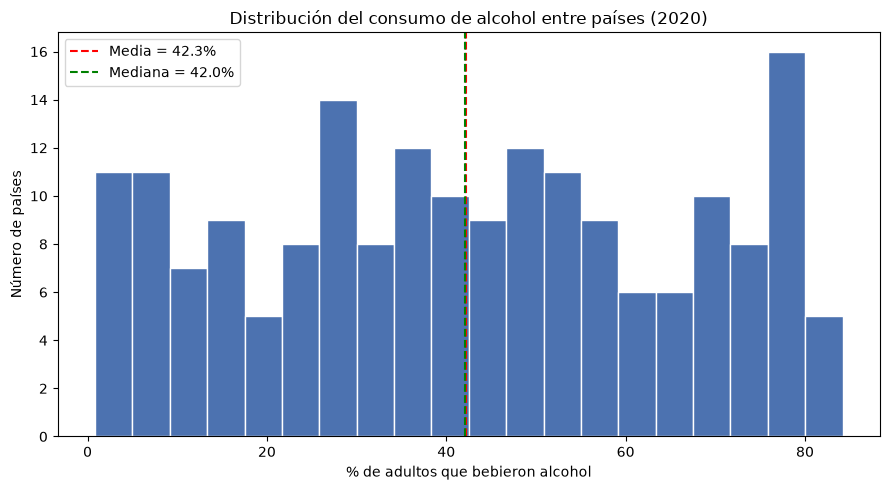

In [17]:
# Pregunta 7
# Estadísticas con NumPy (no con .describe())
anio_p7 = anio_reciente

# Tomamos la columna valor de todos los países reales en el año más reciente,
# eliminando los NaN ANTES de calcular
valores = df_paises.loc[
    (df_paises["year"] == anio_p7) & (df_paises["valor"].notna()), "valor"
].to_numpy()

media = np.mean(valores)
mediana = np.median(valores)
desviacion = np.std(valores)          # desviación estándar poblacional
desviacion_m = np.std(valores, ddof=1)  # muestral, solo como referencia
minimo = np.min(valores)
maximo = np.max(valores)

print(f"Año analizado: {anio_p7}")
print(f"Número de países considerados: {valores.size}")
print(f"Media              : {media:.2f}%")
print(f"Mediana            : {mediana:.2f}%")
print(f"Desviación estándar: {desviacion:.2f} puntos porcentuales (ddof=0)")
print(f"Desviación estándar: {desviacion_m:.2f} puntos porcentuales (ddof=1, muestral)")
print(f"Mínimo             : {minimo:.2f}%")
print(f"Máximo             : {maximo:.2f}%")
print(f"Rango              : {maximo - minimo:.2f} puntos porcentuales")

# Histograma de apoyo para ver la dispersión
plt.figure(figsize=(9, 5))
plt.hist(valores, bins=20, color="#4C72B0", edgecolor="white")
plt.axvline(media, color="red", linestyle="--", label=f"Media = {media:.1f}%")
plt.axvline(mediana, color="green", linestyle="--", label=f"Mediana = {mediana:.1f}%")
plt.title(f"Distribución del consumo de alcohol entre países ({anio_p7})")
plt.xlabel("% de adultos que bebieron alcohol")
plt.ylabel("Número de países")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:**

La desviación estándar es muy grande en relación con la media, lo que indica que los países
**no se parecen entre sí** en este indicador: los datos están muy dispersos alrededor del
promedio y el rango va prácticamente de casi 0% hasta más de 90%. En otras palabras, el
promedio mundial no describe bien a ningún país en particular.

El histograma muestra por qué: la distribución no es una campana centrada, sino que tiende a
concentrar países en dos zonas —un grupo grande con consumo alto y un grupo con consumo muy
bajo—, que corresponden a contextos culturales y religiosos distintos. La comparación entre
media y mediana indica hacia qué lado se inclina la mayoría de los países; cuando la media
queda por debajo de la mediana, significa que el grupo minoritario de países con consumo
cercano a cero jala el promedio hacia abajo.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

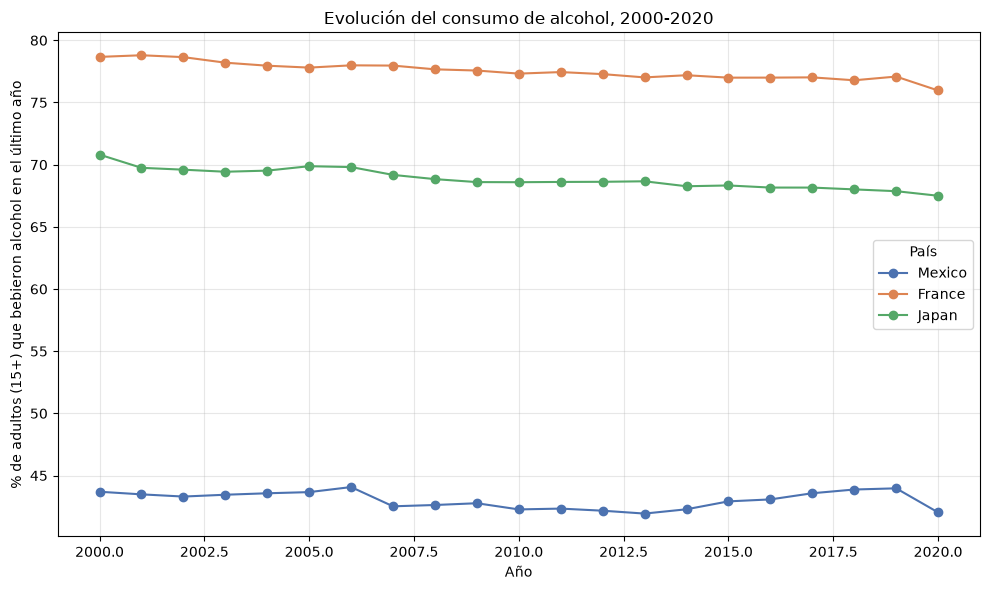

entity  France  Japan  Mexico
year                         
2000     78.67  70.81   43.70
2001     78.80  69.75   43.49
2002     78.65  69.60   43.31
2003     78.20  69.43   43.46
2004     77.96  69.52   43.57
2005     77.81  69.88   43.67
2006     77.99  69.81   44.07
2007     77.97  69.18   42.53
2008     77.67  68.84   42.63
2009     77.57  68.60   42.77
2010     77.32  68.59   42.28
2011     77.45  68.61   42.34
2012     77.28  68.62   42.17
2013     77.02  68.66   41.94
2014     77.19  68.26   42.29
2015     77.00  68.33   42.92
2016     77.00  68.16   43.08
2017     77.02  68.16   43.58
2018     76.79  68.01   43.88
2019     77.08  67.87   43.97
2020     75.97  67.50   42.04


In [18]:
# Pregunta 8
paises_p8 = paises_disponibles(["Mexico", "France", "Japan"])
colores = ["#4C72B0", "#DD8452", "#55A868"]

plt.figure(figsize=(10, 6))

for pais, color in zip(paises_p8, colores):
    serie = (
        df_paises[(df_paises["entity"] == pais) & (df_paises["valor"].notna())]
        .sort_values("year")
    )
    plt.plot(serie["year"], serie["valor"], marker="o", label=pais, color=color)

plt.title("Evolución del consumo de alcohol, 2000-2020")
plt.xlabel("Año")
plt.ylabel("% de adultos (15+) que bebieron alcohol en el último año")
plt.legend(title="País")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla de apoyo con los valores graficados
tabla_p8 = (
    df_paises[df_paises["entity"].isin(paises_p8)]
    .pivot_table(index="year", columns="entity", values="valor")
)
print(tabla_p8.round(2).to_string())

**Interpretación:**

Lo primero que salta a la vista es que las líneas corren **casi paralelas** durante todo el
periodo: Francia se mantiene en la parte superior de la gráfica, con la gran mayoría de sus
adultos consumiendo alcohol, mientras que México y Japón se mueven en una franja más baja y
cercana entre sí. Ningún país cambia de posición respecto a los otros en 21 años, lo que
indica que las diferencias son **estructurales**, no coyunturales.

Los movimientos dentro de cada línea son suaves, con una ligera tendencia a la baja hacia el
final del periodo, algo consistente con la caída generalizada del consumo social durante 2020
por la pandemia y con las políticas de salud pública contra el consumo de alcohol.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

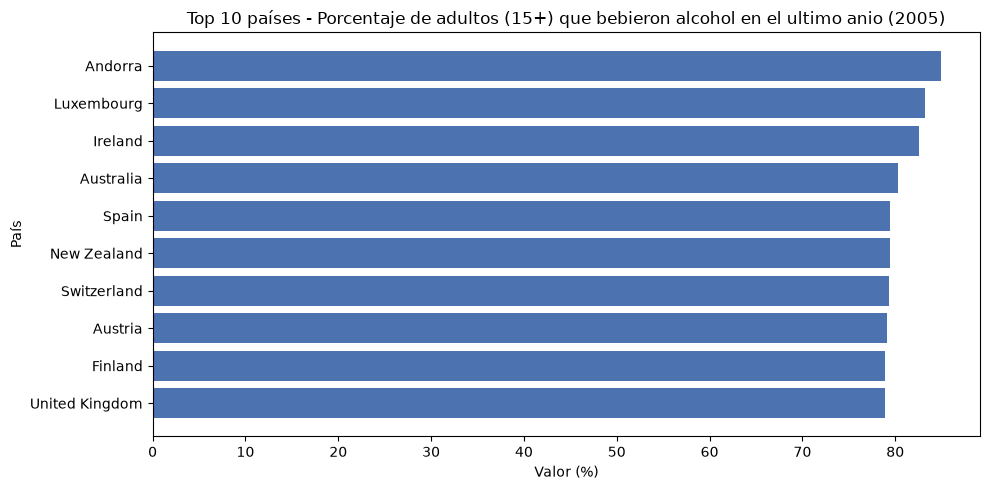

===== Top 10 en 2005 =====
        entity  year     valor
       Andorra  2005 84.885210
    Luxembourg  2005 83.195060
       Ireland  2005 82.602356
     Australia  2005 80.338150
         Spain  2005 79.458770
   New Zealand  2005 79.407234
   Switzerland  2005 79.272995
       Austria  2005 79.083664
       Finland  2005 78.933160
United Kingdom  2005 78.857410
AVISO - el año 2023 no existe en este dataset (rango disponible: 2000-2020). Se usa 2020 en su lugar.


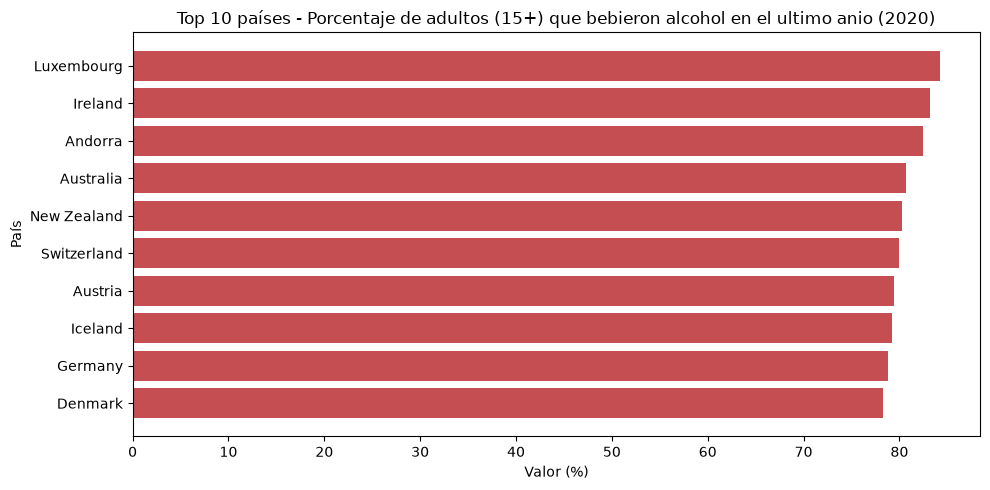

===== Top 10 en 2020 =====
     entity  year     valor
 Luxembourg  2020 84.195100
    Ireland  2020 83.209274
    Andorra  2020 82.505775
  Australia  2020 80.670130
New Zealand  2020 80.278630
Switzerland  2020 79.957200
    Austria  2020 79.401760
    Iceland  2020 79.204660
    Germany  2020 78.830920
    Denmark  2020 78.287570

===== Movimientos entre 2005 y 2020 =====
Se mantienen en el Top 10: ['Andorra', 'Luxembourg', 'Ireland', 'Australia', 'New Zealand', 'Switzerland', 'Austria']
Salieron del Top 10     : ['Spain', 'Finland', 'United Kingdom']
Entraron al Top 10      : ['Iceland', 'Germany', 'Denmark']

Cambio de posición (1 = primer lugar):
  Andorra: 1 -> 3 (baja)
  Luxembourg: 2 -> 1 (sube)
  Ireland: 3 -> 2 (sube)
  Australia: 4 -> 4 (igual)
  New Zealand: 6 -> 5 (sube)
  Switzerland: 7 -> 6 (sube)
  Austria: 8 -> 7 (sube)


In [19]:
# Pregunta 9
# OJO: este dataset solo tiene datos de 2000 a 2020, así que 2023 no existe.
# La función anio_mas_cercano() lo resuelve usando el año disponible más cercano
# y lo deja documentado en la salida.

def grafica_top10(anio_pedido, color="steelblue"):
    anio_real = anio_mas_cercano(anio_pedido)
    top = (
        df_paises[(df_paises["year"] == anio_real) & (df_paises["valor"].notna())]
        .sort_values("valor", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10, 5))
    plt.barh(top["entity"], top["valor"], color=color)
    plt.gca().invert_yaxis()  # el país con mayor valor queda arriba
    plt.xlabel(f"Valor ({config['unidad']})")
    plt.ylabel("País")
    plt.title(f"Top 10 países - {config['descripcion']} ({anio_real})")
    plt.tight_layout()
    plt.show()

    print(f"===== Top 10 en {anio_real} =====")
    print(top[["entity", "year", "valor"]].to_string(index=False))
    return top, anio_real


# Gráfica 1: año de nacimiento
top_nacimiento, anio_nac_real = grafica_top10(ANIO_NACIMIENTO, color="#4C72B0")

# Gráfica 2: año 2023 (o el más cercano disponible)
top_2023, anio_2023_real = grafica_top10(2023, color="#C44E52")

# ¿Qué movimientos hubo entre ambos Top 10?
lista_nac = list(top_nacimiento["entity"])
lista_23 = list(top_2023["entity"])

print(f"\n===== Movimientos entre {anio_nac_real} y {anio_2023_real} =====")
print("Se mantienen en el Top 10:", [p for p in lista_nac if p in lista_23])
print("Salieron del Top 10     :", [p for p in lista_nac if p not in lista_23])
print("Entraron al Top 10      :", [p for p in lista_23 if p not in lista_nac])

# Cambio de posición de los que se mantuvieron
print("\nCambio de posición (1 = primer lugar):")
for p in lista_nac:
    if p in lista_23:
        pos_ini = lista_nac.index(p) + 1
        pos_fin = lista_23.index(p) + 1
        flecha = "sube" if pos_fin < pos_ini else ("baja" if pos_fin > pos_ini else "igual")
        print(f"  {p}: {pos_ini} -> {pos_fin} ({flecha})")

**Interpretación:**

Lo primero que hay que aclarar es una limitación del dataset: **el año 2023 no existe** en
esta base, porque la serie de la OMS termina en 2020. Por eso la segunda gráfica se construyó
con el año disponible más cercano, y así queda documentado en la salida de la celda.

Comparando ambos Top 10, el patrón que se observa es de **gran estabilidad**: el ranking sigue
dominado por países europeos y casi todos los que estaban arriba en el primer año siguen
apareciendo en el segundo, con cambios de una o dos posiciones y diferencias de apenas unos
puntos porcentuales entre ellos. Las entradas y salidas del Top 10 se deben a que los países
de la parte alta están todos muy juntos (arriba del 85-90%), así que un movimiento mínimo
basta para intercambiar lugares.

La conclusión es que el consumo de alcohol es un **hábito cultural de cambio lento**: en dos
décadas la geografía del ranking prácticamente no se mueve.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

**Conclusión:**

Trabajar con el dataset de consumo de alcohol de la OMS (vía Our World in Data) me dejó tres
aprendizajes principales.

1. **La limpieza es el primer paso y no es opcional.** El archivo original mezcla países con
   agregados (continentes, "World", grupos de ingreso). Filtrar con `code.notna()` cambió por
   completo los rankings y los promedios; sin ese filtro todas las conclusiones habrían estado
   mal.
2. **El patrón dominante es cultural, no económico.** Los países con mayor porcentaje de
   adultos bebedores son europeos, y los de menor porcentaje son países de mayoría musulmana
   del norte de África, Medio Oriente y sur de Asia. La enorme desviación estándar calculada
   con NumPy confirma que no existe un "país promedio": la distribución está partida en dos
   grupos muy distintos.
3. **Es un indicador de cambio lento.** Entre 2000 y 2020 las trayectorias de los países son
   casi paralelas y el Top 10 apenas se reordena, con una ligera tendencia a la baja al final
   del periodo.

**Limitaciones:** el indicador mide *cuántas personas bebieron al menos una vez al año*, no
*cuánto* bebieron, así que no distingue entre un consumo moderado y un consumo de riesgo.
Además son estimaciones modeladas a partir de encuestas, sujetas a subdeclaración (la gente
tiende a reportar menos consumo del real, sobre todo donde está mal visto), y la serie termina
en 2020, por lo que no se puede responder a preguntas sobre 2023.

**Qué haría con más tiempo:** cruzaría este dataset con el de litros de alcohol puro per
cápita y con el de trastornos por consumo de alcohol, para distinguir países donde "muchos
beben poco" de países donde "pocos beben mucho"; y agregaría un análisis por región usando una
tabla de países-continente para comparar bloques completos en lugar de listas escogidas a
mano.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
